# setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
def scatter(a, b, log=False, log10=False, diag=True, ma=0, ax=None, c='black', s=1,
            label=None, alpha=1, aspect=False, cmap=None, return_scat_obj=False, args={}):
    # Scatters a vs b of ax (default plt). Can apply:
    #   -   log(x+1) transformation (optional)
    #   -   label (optional)
    #   -   color (default black)
    #   -   size of point (default 1)
    #   -   alpha factor (default 1)
    #   -   aspect ratio equal (optional)
    #   -   diagonal line from 0 to ma (if provided) or to max(a,b) (optional)

    ax_ = ax if ax is not None else plt
    if log:
        a = a+1
        b = b+1
        ax_.semilogx(base=2)
        ax_.semilogy(base=2)
    elif log10:
        a = a+1
        b = b+1
        ax_.semilogx(base=10)
        ax_.semilogy(base=10)
    if diag:
        if ma == 0: ma = np.max([a.max(), b.max()])
        ax_.plot([0, ma], [0, ma], linewidth=1, c='black')
    if type(c) is str or type(c) == np.ndarray:
        scat = ax_.scatter(a, b, s=s, c=c, alpha=alpha, label=label, cmap=cmap, **args)
    else:
        scat = ax_.scatter(a, b, s=s, color=c, alpha=alpha, label=label, cmap=cmap, **args)
    if aspect:
        if ax is None: ax_.gca().set_aspect('equal')
        else: ax_.set_aspect('equal')
    if return_scat_obj: return ax_, scat
    else: return ax_



def add_labels(title=None, xlabel=None, ylabel=None, xlim=None, ylim=None,
               xticks=None, xticklabels=None, xtickrotation=None,
               yticks=None, yticklabels=None, ytickrotation=None,
               aspect=False, legend=False, ax=None):
    # Applies labels (if provided)

    if ax is None or ax is plt:
        if title is not None: plt.title(title)
        if xlabel is not None: plt.xlabel(xlabel)
        if ylabel is not None: plt.ylabel(ylabel)
        if xlim is not None: plt.xlim(xlim)
        if ylim is not None: plt.ylim(ylim)
        if xticks is not None:
            if xtickrotation is not None: plt.xticks(xticks, xticklabels, rotation=xtickrotation)
            else: plt.xticks(xticks, xticklabels)
        if yticks is not None:
            if ytickrotation is not None: plt.yticks(yticks, yticklabels, rotation=ytickrotation)
            else: plt.yticks(yticks, yticklabels)
        if aspect: plt.gca().set_aspect('equal')
        if legend: plt.legend()
        return plt
    else:
        if title is not None: ax.set_title(title)
        if xlabel is not None: ax.set_xlabel(xlabel)
        if ylabel is not None: ax.set_ylabel(ylabel)
        if xlim is not None: ax.set_xlim(xlim)
        if ylim is not None: ax.set_ylim(ylim)
        if xticks is not None: ax.set_xticks(xticks)
        if yticks is not None: ax.set_yticks(yticks)
        if xticklabels is not None:
            if xtickrotation is not None: ax.set_xticklabels(xticklabels, rotation=xtickrotation)
            else: ax.set_xticklabels(xticklabels)
        if yticklabels is not None:
            if ytickrotation is not None: ax.set_yticklabels(yticklabels, rotation=ytickrotation)
            else: ax.set_yticklabels(yticklabels)
        if aspect: ax.set_aspect('equal')
        if legend: ax.legend()
        return ax


def show(title=None, xlabel=None, ylabel=None, xlim=None, ylim=None, aspect=False,
         fig=plt, figname=None, tight_layout=True, dpi=300,
         savefig=True, showfig=True, legend=False, savepdf=False):
    # Finishes plot:
    #   -   Applies labels (if provided)
    #   -   Applies legend and tight_layout (optional)
    #   -   Saves to figname (optional)
    #   -   Shows fig (optional - otherwise delete it)

    if type(fig) is plt.Figure and title is not None: fig.suptitle(title)
    if type(fig) is not plt.Figure:
        add_labels(title=title, xlabel=xlabel, ylabel=ylabel, xlim=xlim, ylim=ylim, aspect=aspect, ax=None)
    else:
        add_labels(xlabel=xlabel, ylabel=ylabel, aspect=aspect, ax=None)

    if legend: plt.legend()
    if tight_layout: fig.tight_layout()
    if savefig and figname is not None: fig.savefig(figname.parent/f'{figname.name}.png', dpi=dpi)
    if savepdf and figname is not None: fig.savefig(figname.parent/f'{figname.name}.pdf')
    if showfig: plt.show()
    else: fig.clf()

# Loading data

### Resolving Path issue

In [3]:
from pathlib import Path

# samples files
healthy_path = Path('C:/Users/saris/OneDrive/University/Year3/project/new_git/cancer-signal-decomposition/data/real/GeneMatrix_H3K4me3_healthy.csv')
diseaseA_path = Path('C:/Users/saris/OneDrive/University/Year3/project/new_git/cancer-signal-decomposition/data/real/GeneMatrix_H3K4me3_crc.csv')
diseaseB_path = Path('C:/Users/saris/OneDrive/University/Year3/project/new_git/cancer-signal-decomposition/data/real/GeneMatrix_H3K4me3_sclc.csv')
# thetas files
theta_A_path = Path('C:/Users/saris/OneDrive/University/Year3/project/new_git/cancer-signal-decomposition/data/real/theta_CRC_passedQC.csv')
theta_B_path = Path('C:/Users/saris/OneDrive/University/Year3/project/new_git/cancer-signal-decomposition/data/real/SCLC_theta.csv')

print(f'{healthy_path}')

C:\Users\saris\OneDrive\University\Year3\project\new_git\cancer-signal-decomposition\data\real\GeneMatrix_H3K4me3_healthy.csv


### Load read data

In [4]:
import pandas as pd


# loading real data
df_real_healthy = pd.read_csv(healthy_path, index_col=0)
df_real_cancerA = pd.read_csv(diseaseA_path, index_col=0)
df_real_cancerB = pd.read_csv(diseaseB_path, index_col=0)

# loading thetas
metadata_A = pd.read_csv(theta_A_path)
metadata_B = pd.read_csv(theta_B_path)

# Creating Profiles

In [5]:
# average healthy data
blueprint_healthy = df_real_healthy.mean(axis=1).values
print(blueprint_healthy)
print(f"blueprint healthy sum is: {blueprint_healthy.sum()}")

# extract max sample for disease A
max_idx_A = metadata_A['data_list'].idxmax()
sample_A = metadata_A.loc[max_idx_A, 'Unnamed: 0']
theta_A = metadata_A.loc[max_idx_A, 'data_list']
blueprint_A_mixed = df_real_cancerA[sample_A].values
print(f"blueprint DiseaseA sum is: {blueprint_A_mixed.sum()}")

# extract max sample for disease B
max_idx_B = metadata_B['data_list'].idxmax()
sample_B = metadata_B.loc[max_idx_B, 'Unnamed: 0']
theta_B = metadata_B.loc[max_idx_B, 'data_list']
print(f"Healthy profile: Averaged {df_real_healthy.shape[1]} samples.")
print(f"Disease A Max - Sample: {sample_A}, Theta: {theta_A:.4f}")
print(f"Disease B Max - Sample: {sample_B}, Theta: {theta_B:.4f}")
blueprint_B_mixed = df_real_cancerB[sample_B].values
print(f"blueprint DiseaseB sum is: {blueprint_B_mixed.sum()}")


print(f"BlueprintAMixed is {blueprint_A_mixed} with shape {blueprint_A_mixed.shape}")
print(f"BlueprintBMixed is {blueprint_B_mixed} with shape {blueprint_B_mixed.shape}")

[  2.07904674   5.10471699   2.86391555 ... 254.5102812  172.04307859
  86.57732193]
blueprint healthy sum is: 920976.4895023068
blueprint DiseaseA sum is: 873688.0298266432
Healthy profile: Averaged 750 samples.
Disease A Max - Sample: CRC0001-2746_NA_H3K4me3-L_26082018-L, Theta: 0.7882
Disease B Max - Sample: SCLC0275-602_NA_H3K4me3-697_19052023-92, Theta: 0.9992
blueprint DiseaseB sum is: 1082741.5526501057
BlueprintAMixed is [0.00000000e+00 6.05526492e+01 4.29089976e-02 ... 1.88477423e+02
 8.45671414e+01 6.59897736e+01] with shape (20006,)
BlueprintBMixed is [  9.86742269   0.26202123   0.         ... 245.05850017 123.40493332
  60.72137523] with shape (20006,)


### Isolting Cancer

In [6]:
# isolating disease A
pure_disease_A = (blueprint_A_mixed - (1 - theta_A) * blueprint_healthy) / theta_A
pure_disease_A = pure_disease_A.clip(min=0)

# isolating disease B
pure_disease_B = (blueprint_B_mixed - (1 - theta_B) * blueprint_healthy) / theta_B
pure_disease_B = pure_disease_B.clip(min=0)

print("Successfully isolated pure Disease A and Disease B profiles.")

Successfully isolated pure Disease A and Disease B profiles.


### Pure datasets

In [7]:
n_genes = len(blueprint_healthy)
n_healthy_samples = 300
n_disease_A_samples = 200
n_disease_B_samples = 200
bio_noise_std = 0.1

total_healthy_needed = n_healthy_samples + n_disease_A_samples + n_disease_B_samples

healthy_pool = np.random.normal(
    blueprint_healthy[:, None], bio_noise_std, size=(n_genes, total_healthy_needed)
).clip(min=0)

disease_A_pool = np.random.normal(
    pure_disease_A[:, None], bio_noise_std, size=(n_genes, n_disease_A_samples)
).clip(min=0)

disease_B_pool = np.random.normal(
    pure_disease_B[:, None], bio_noise_std, size=(n_genes, n_disease_B_samples)
).clip(min=0)

pure_healthy_data = healthy_pool[:, :n_healthy_samples]


print(f"Pools created: Healthy ({healthy_pool.shape}), Disease A ({disease_A_pool.shape}), Disease B ({disease_B_pool.shape})")

Pools created: Healthy ((20006, 700)), Disease A ((20006, 200)), Disease B ((20006, 200))


In [ ]:
def apply_sequencing_noise(clean_matrix):
    """
    Func to apply poisson technical noise. Does so by anchoring the variance to sequencing depth (0.5M to 5M).
    Returns the normalized, noisy matrix.
    """
    n_samples = clean_matrix.shape[1]
    target_depths = np.random.uniform(500_000, 5_000_000, size=n_samples)
    scaling_factors = (target_depths / 1_000_000).reshape(1, -1) ## shape 1 row n cols
    ## example: if we get 3M for target depth, the scaling is 3 (since sum is roughly 1M) 
    
    expected_counts = clean_matrix * scaling_factors ## multiply by the scaling
    raw_synthetic_counts = np.random.poisson(lam=expected_counts) ## apply our poisson
    
    # Normalize back to stabilize the variance
    return raw_synthetic_counts / scaling_factors ## normalize by the scaling factor
# # Mixing

In [ ]:
n_mix = n_disease_A_samples ##NOTE for now its fine, num of A and B samples is the same

# mix disease A
thetas_A = np.random.uniform(0,1,n_mix)
healthy_data_samples_A = healthy_pool[:, n_healthy_samples:n_healthy_samples+n_mix] # healthy bio noisy parts for A samples

mixed_A_clean = (1 - thetas_A) * healthy_data_samples_A + thetas_A * disease_A_pool # clean := no sample/tech noise

# mix disease B
thetas_B = np.random.uniform(0, 1, n_mix)
healthy_data_samples_B = healthy_pool[:, n_mix + n_healthy_samples:]

mixed_B_clean = (1 - thetas_B) * healthy_data_samples_B + thetas_B * disease_B_pool

print(f"Created mixtures. Mix A shape: {mixed_A_clean.shape}, Mix B shape: {mixed_B_clean.shape}")
print(f"healthy data samples: {healthy_data_samples_A.shape}")

## applying tech noise
final_mixed_A = apply_sequencing_noise(mixed_A_clean)
final_mixed_B = apply_sequencing_noise(mixed_B_clean)
final_healthy = apply_sequencing_noise(pure_healthy_data)

Created mixtures. Mix A shape: (20006, 200), Mix B shape: (20006, 200)
healthy data samples: (20006, 200)


## Saving

In [10]:

df_healthy = pd.DataFrame(final_healthy, index=df_real_healthy.index, 
                          columns=[f'Healthy-Sample{i}' for i in range(pure_healthy_data.shape[1])])
df_healthy.to_csv('healthy_data.csv')

# 3. Save Pure Disease Profiles
df_pure_A = pd.DataFrame(disease_A_pool, index=df_real_healthy.index, 
                         columns=[f'DiseaseA-Sample{i}' for i in range(disease_A_pool.shape[1])])
# df_pure_A.to_csv('pure_disease_A.csv')

df_pure_B = pd.DataFrame(disease_B_pool, index=df_real_healthy.index, 
                         columns=[f'DiseaseB-Sample{i}' for i in range(disease_B_pool.shape[1])])
# df_pure_B.to_csv('pure_disease_B.csv')

# 4. Save Mixed Data A and its Theta values
df_mixed_A = pd.DataFrame(final_mixed_A, index=df_real_healthy.index, 
                          columns=[f'DiseaseA-Sample{i}' for i in range(final_mixed_A.shape[1])])
# df_mixed_A.to_csv('mixed_data_A.csv')
# pd.Series(thetas_A, name='Theta').to_csv('mixed_A_thetas.csv', index=False)

# 5. Save Mixed Data B and its Theta values
df_mixed_B = pd.DataFrame(final_mixed_B, index=df_real_healthy.index, 
                          columns=[f'DiseaseB-Sample{i}' for i in range(final_mixed_B.shape[1])])
# df_mixed_B.to_csv('mixed_data_B.csv')
# pd.Series(thetas_B, name='Theta').to_csv('mixed_B_thetas.csv', index=False)

# print(f"All components saved")

SAVE COMBINED DATASETS


In [11]:
labels_A = np.ones(len(thetas_A), dtype=int)
labels_B = np.full(len(thetas_B), 2, dtype=int)
all_labels = np.concatenate([labels_A, labels_B])

## save one combined csv of the pure disease truth of each disease sample (a and b)
combined_pure_df = pd.concat([df_pure_A, df_pure_B], axis=1)
combined_pure_df.to_csv("pure_disease_truth.csv")
print(combined_pure_df.shape)

## save theta values of all disease samples in one file
all_thetas = np.concatenate([thetas_A, thetas_B])

# Extract the exact sample names you generated earlier to ensure perfect alignment
sample_names = list(df_mixed_A.columns) + list(df_mixed_B.columns)

# Build the combined metadata DataFrame
combined_theta_df = pd.DataFrame({
    'theta_value': all_thetas,
    'disease_type': all_labels
}, index=sample_names)

combined_theta_df.to_csv("theta_values.csv", index=True)
print(f"Combined Theta Shape: {combined_theta_df.shape}")

(20006, 400)
Combined Theta Shape: (400, 2)


In [13]:
# =========================================================
# 1. COMBINE AND SAVE: Uniform Theta Mixed Data
# =========================================================
# We use axis=1 to stack the 150 'B' patients next to the 150 'A' patients
combined_mixed_uniform_df = pd.concat([df_mixed_A, df_mixed_B], axis=1)
combined_mixed_uniform_df.loc['disease_type'] = all_labels
combined_mixed_uniform_df.to_csv("disease_data_uniform_theta.csv")

print(f"Saved Uniform Theta Mix. Shape: {combined_mixed_uniform_df.shape}") 
# Expected: (20000, 300)

# =========================================================
# 2. GENERATE, COMBINE, AND SAVE: Fixed Theta (0.5) Mixed Data
# =========================================================
fixed_theta = 0.5

# Mix the data using the fixed 0.5 ratio
# We reuse healthy_data_samples_A/B so the background noise is consistent!
mixed_A_05_clean = (1 - fixed_theta) * healthy_data_samples_A + fixed_theta * disease_A_pool
mixed_B_05_clean = (1 - fixed_theta) * healthy_data_samples_B + fixed_theta * disease_B_pool

final_mixed_A_05 = apply_sequencing_noise(mixed_A_05_clean)
final_mixed_B_05 = apply_sequencing_noise(mixed_B_05_clean)
# Convert these new matrices into Pandas DataFrames
df_mixed_A_05 = pd.DataFrame(
    final_mixed_A_05, 
    index=df_real_healthy.index, 
    columns=[f'DiseaseA-Sample{i}' for i in range(final_mixed_A_05.shape[1])]
)

df_mixed_B_05 = pd.DataFrame(
    final_mixed_B_05, 
    index=df_real_healthy.index, 
    columns=[f'DiseaseB-Sample{i}' for i in range(final_mixed_B_05.shape[1])]
)

# Combine them side-by-side
combined_mixed_05_df = pd.concat([df_mixed_A_05, df_mixed_B_05], axis=1)
combined_mixed_05_df.loc['disease_type'] = all_labels
combined_mixed_05_df.to_csv("disease_data_theta05.csv")

print(f"Saved Fixed Theta (0.5) Mix. Shape: {combined_mixed_05_df.shape}")
# Expected: (20000, 400)

Saved Uniform Theta Mix. Shape: (20007, 400)
Saved Fixed Theta (0.5) Mix. Shape: (20007, 400)


## Raw Data PCA Baseline (or Pre-Training Sanity Check)

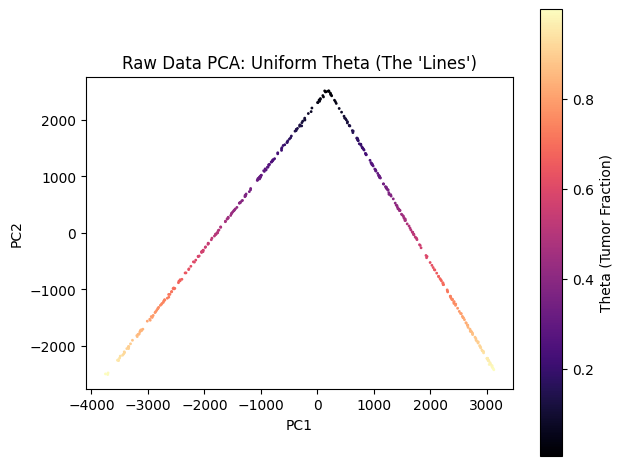

In [14]:
from sklearn.decomposition import PCA

# 1. Prep the Uniform Theta data (drop the label row and transpose so samples are rows)
raw_uniform_data = combined_mixed_uniform_df.drop('disease_type').values.T 

# 2. Run PCA directly on the raw, noisy sequence counts
pca_coords_uniform = PCA(n_components=2).fit_transform(raw_uniform_data)

# 3. Plot it using the custom functions at the top of your script
# Coloring by 'all_thetas' to see the continuous gradients (the "lines")
ax, scat = scatter(pca_coords_uniform[:, 0], pca_coords_uniform[:, 1], 
                   c=all_thetas, cmap='magma', return_scat_obj=True, diag=False)

# Add a colorbar and labels
plt.colorbar(scat, label="Theta (Tumor Fraction)")
show(title="Raw Data PCA: Uniform Theta (The 'Lines')", 
     xlabel="PC1", ylabel="PC2", aspect=True)

## Raw Data PCA: Uniform Theta by Disease Type

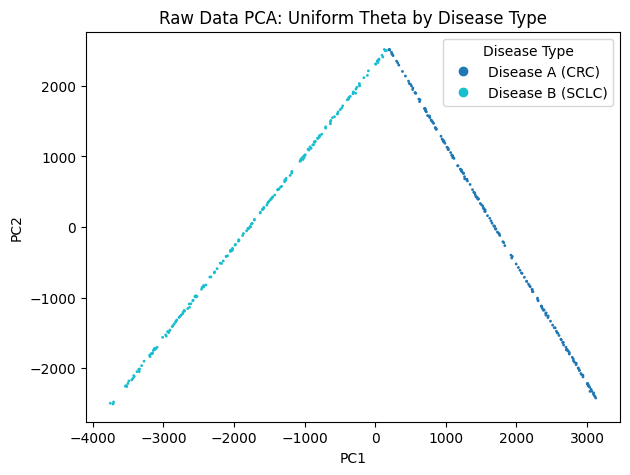

In [15]:
# 1. Plot using disease_type (all_labels) instead of theta
# Set diag=False to remove the weird black line!
ax, scat = scatter(pca_coords_uniform[:, 0], pca_coords_uniform[:, 1], 
                   c=all_labels, cmap='tab10', diag=False, return_scat_obj=True)

# 2. Add a legend for the discrete disease types
# Since tab10 is categorical, a legend works better than a colorbar
handles, _ = scat.legend_elements(prop="colors")
ax.legend(handles, ["Disease A (CRC)", "Disease B (SCLC)"], title="Disease Type")

show(title="Raw Data PCA: Uniform Theta by Disease Type", 
     xlabel="PC1", ylabel="PC2", aspect=True)